# 02 — Preprocessing Pipeline
### Brand Sentiment Monitor

**What this notebook does:**
Builds and validates the text cleaning pipeline (`src/preprocessing/cleaner.py`),
applies it to all three Kaggle datasets, and saves processed CSVs that
notebooks 04, 05, and 07 will use for training.

**EDA decisions implemented here:**
- Finding 2 → max_length=128 (verify coverage after cleaning)
- Finding 3 → remove URLs, @mentions, convert emoji, normalize repeated chars

**Outputs:**
```
data/kaggle/processed/s140_clean.csv       (sentiment140 cleaned)
data/kaggle/processed/goemotions_clean.csv (goemotions cleaned)
data/kaggle/processed/semeval_clean.csv    (semeval cleaned)
data/kaggle/processed/pipeline_stats.json (coverage + token stats)
```

---
Run notebooks 00 and 01 first.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, sys, json, re, ast, warnings
warnings.filterwarnings("ignore")

DRIVE_ROOT  = "/content/drive/MyDrive/brand-sentiment-monitor"
KAGGLE_RAW  = os.path.join(DRIVE_ROOT, "data/kaggle/raw")
KAGGLE_PROC = os.path.join(DRIVE_ROOT, "data/kaggle/processed")

os.makedirs(KAGGLE_PROC, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

plt.rcParams.update({"figure.figsize": (13, 4), "font.size": 12})
pd.set_option("display.max_colwidth", 120)


## 1. Load EDA Decisions
Load findings from notebook 01 to confirm this notebook implements the right decisions.

In [ ]:
with open(os.path.join(DRIVE_ROOT, "outputs/reports/eda_decisions.json")) as f:
    decisions = json.load(f)
with open(os.path.join(DRIVE_ROOT, "outputs/reports/eda_metadata.json")) as f:
    meta = json.load(f)

# Show decisions that apply to this notebook
nb02_decisions = {v['id']: v for v in decisions if "02" in v.get("notebook", "")}
print("Decisions implemented in notebook 02:")
for k, v in nb02_decisions.items():
    print(f"  [{k}] {v['finding']}")
    print(f"        → {v['decision']}")

MAX_LENGTH = meta["sentiment140"]["max_length"]
print(f"\nmax_length = {MAX_LENGTH}  (from EDA Finding 2)")

Decisions implemented in notebook 02:
  [2] P95 token length <= 128
        → max_length=128 all models
  [3] URL / mention / emoji noise
        → Remove URL+mention, convert emoji, keep ALL CAPS
  [13] Irony markers: high ! and ... usage
        → Keep punctuation in preprocessing
  [21] Negation patterns significantly more common in negative class
        → Keep contractions expansion in preprocessing so 'not' tokenizes correctly

max_length = 128  (from EDA Finding 2)


## 2. Cleaner — What It Does and Why

`src/preprocessing/cleaner.py` applies these steps in order:

| Step | What | Why |
|------|------|-----|
| Unicode fix | encode → decode utf-8 | removes corrupt bytes |
| Remove URLs | `https://...` → `` | zero sentiment signal |
| Remove @mentions | `@user` → `` | zero sentiment signal |
| Strip # from hashtag | `#Nike` → `Nike` | keep the word, drop the symbol |
| Emoji → text token | 😡 → `:enraged_face:` | preserve emotional signal |
| Expand contractions | `don't` → `do not` | helps BERT tokenizer |
| Normalize repeated chars | `loooove` → `loove` | normalizes informal text |
| Collapse whitespace | multiple spaces → one | cleanup |

**Deliberately NOT done:**
- Lowercase — BERT is cased, ALL CAPS carries anger/emphasis signal
- Stopword removal — BERT needs full sentence context
- Lemmatization — BERT's subword tokenizer handles morphology internally

In [ ]:
# Install cleaning deps if not already present
import importlib
for pkg in ["emoji", "contractions"]:
    if importlib.util.find_spec(pkg) is None:
        import subprocess
        subprocess.run(["pip", "install", "-q", pkg])

import emoji
import contractions

def clean(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.encode("utf-8", errors="ignore").decode("utf-8")
    text = re.sub(r"https?://\S+",  "", text)
    text = re.sub(r"@\w+",          "", text)
    text = re.sub(r"#(\w+)",        r"\1", text)
    text = emoji.demojize(text, delimiters=(" :", ": "))
    text = contractions.fix(text)
    text = re.sub(r"(.)\1{2,}",     r"\1\1", text)
    text = re.sub(r"\s+",           " ",       text)
    return text.strip()

print("clean() defined ✅")


clean() defined ✅


## 3. Step-by-Step Trace
Verify each cleaning step on real examples before applying to 1.6M rows.

In [ ]:
examples = [
    "Check out https://nike.com/new-drop — looks amazing!! 😍😍😍",
    "@adidas your new shoes are sooooo uncomfortable!!!",
    "#Nike just dropped the collab and I CANT EVEN 🔥🔥",
    "I don't think puma's quality has improved at all tbh",
    "Ordered Reebok last week. Still waiting...  No updates from @ReebokSupport",
    "Oh great, another Nike product that broke in a week. Love it 🙄",   # sarcasm
]

steps = [
    ("original",          lambda t: t),
    ("unicode fix",       lambda t: t.encode("utf-8", errors="ignore").decode("utf-8")),
    ("remove URL",        lambda t: re.sub(r"https?://\S+", "", t)),
    ("remove @mention",   lambda t: re.sub(r"@\w+", "", t)),
    ("strip # symbol",    lambda t: re.sub(r"#(\w+)", r"\1", t)),
    ("emoji → token",     lambda t: emoji.demojize(t, delimiters=(" :", ": "))),
    ("expand contraction",lambda t: contractions.fix(t)),
    ("norm repeated",     lambda t: re.sub(r"(.)\1{2,}", r"\1\1", t)),
    ("final clean()",     lambda t: clean(t)),
]

for ex in examples:
    print(f"\n{'─'*70}")
    current = ex
    for step_name, fn in steps:
        result = fn(current)
        changed = " ← changed" if result != current else ""
        print(f"  {step_name:<22} {result[:85]}{changed}")
        current = result



──────────────────────────────────────────────────────────────────────
  original               Check out https://nike.com/new-drop — looks amazing!! 😍😍😍
  unicode fix            Check out https://nike.com/new-drop — looks amazing!! 😍😍😍
  remove URL             Check out  — looks amazing!! 😍😍😍 ← changed
  remove @mention        Check out  — looks amazing!! 😍😍😍
  strip # symbol         Check out  — looks amazing!! 😍😍😍
  emoji → token          Check out  — looks amazing!!  :smiling_face_with_heart-eyes:  :smiling_face_with_hear ← changed
  expand contraction     Check out  — looks amazing!!  :smiling_face_with_heart-eyes:  :smiling_face_with_hear
  norm repeated          Check out  — looks amazing!!  :smiling_face_with_heart-eyes:  :smiling_face_with_hear
  final clean()          Check out — looks amazing!! :smiling_face_with_heart-eyes: :smiling_face_with_heart-e ← changed

──────────────────────────────────────────────────────────────────────
  original               @adidas your new 

## 4. Apply to Sentiment140
1.6M rows — uses `progress_apply` to show progress bar.

In [ ]:
s140 = pd.read_csv(
    os.path.join(KAGGLE_RAW, "sentiment140.csv"),
    encoding="latin-1", header=None,
    names=["polarity", "id", "date", "query", "user", "text"]
)
s140["label"] = s140["polarity"].map({0: "negative", 2: "neutral", 4: "positive"})
print(f"Loaded: {s140.shape}")


Loaded: (1600000, 7)


In [ ]:
print("Cleaning 1.6M rows — ~3 min on Colab T4...")
s140["clean_text"] = s140["text"].progress_apply(clean)

# Drop rows where cleaning left nothing usable
before = len(s140)
s140 = s140[s140["clean_text"].str.len() >= 15].reset_index(drop=True)
print(f"Dropped {before - len(s140):,} too-short rows after cleaning")
print(f"Remaining: {len(s140):,}")


Cleaning 1.6M rows — ~3 min on Colab T4...


  0%|          | 0/1600000 [00:00<?, ?it/s]

Dropped 71,209 too-short rows after cleaning
Remaining: 1,528,791


In [ ]:
# Token length check — EDA Finding 2 says P95 ≤ 128
s140["token_est"] = (s140["clean_text"].str.split().str.len() * 1.3).astype(int)
p95 = int(s140["token_est"].quantile(0.95))
coverage = (s140["token_est"] <= MAX_LENGTH).mean() * 100

print(f"Token stats after cleaning:")
print(s140["token_est"].describe(percentiles=[.5, .95, .99]).round(1))
print(f"\nP95          = {p95} tokens")
print(f"Coverage ≤{MAX_LENGTH} = {coverage:.1f}%")
print(f"EDA said P95 = {meta['sentiment140']['p95_tokens']:.0f} — {'✅ consistent' if abs(p95 - meta['sentiment140']['p95_tokens']) < 10 else '⚠️ check'}")


Token stats after cleaning:
count    1528791.0
mean          17.3
std            9.1
min            1.0
50%           16.0
95%           33.0
99%           37.0
max          214.0
Name: token_est, dtype: float64

P95          = 33 tokens
Coverage ≤128 = 100.0%
EDA said P95 = 32 — ✅ consistent


In [ ]:
# Side-by-side: raw vs clean for 6 random rows
sample = s140.sample(6, random_state=42)[["label", "text", "clean_text"]]
for _, row in sample.iterrows():
    print(f"\n[{row['label']}]")
    print(f"  RAW   : {str(row['text'])[:100]}")
    print(f"  CLEAN : {str(row['clean_text'])[:100]}")



[negative]
  RAW   : No baby foxes sighting today. 
  CLEAN : No baby foxes sighting today.

[positive]
  RAW   : @nodgarb You're going to hurt @louiseducray's feelings. We WANT to go, not HAVE to go. Bring some ru
  CLEAN : You are going to hurt 's feelings. We WANT to go, not HAVE to go. Bring some rum.

[negative]
  RAW   : @LouiseMayes  am fine thanks but not sure ironing was mentioned lol - graphs and figures are what I 
  CLEAN : am fine thanks but not sure ironing was mentioned lol - graphs and figures are what I am doing at th

[negative]
  RAW   : Hit the ground running this A.M.  Sadly, the error condition has not been reproducible; so we're no 
  CLEAN : Hit the ground running this A.M. Sadly, the error condition has not been reproducible; so we are no 

[negative]
  RAW   : I have the biggest headache  -LB
  CLEAN : I have the biggest headache -LB

[negative]
  RAW   : come on... drop by 1  102. digg.com
  CLEAN : come on.. drop by 1 102. digg.com


In [ ]:
s140_out = s140[["polarity", "label", "clean_text"]].rename(columns={"clean_text": "text"})
s140_out.to_csv(os.path.join(KAGGLE_PROC, "s140_clean.csv"), index=False)
print(f"Saved → data/kaggle/processed/s140_clean.csv  {s140_out.shape}")


Saved → data/kaggle/processed/s140_clean.csv  (1528791, 3)


## 5. Apply to GoEmotions

In [ ]:
import re

def clean_and_eval_labels(label_value):
    if isinstance(label_value, str):
        # Extract all sequences of digits
        numbers = re.findall(r'\d+', label_value)
        if numbers:
            # Construct a syntactically correct list string, e.g., "[8, 20]"
            return ast.literal_eval(f"[{', '.join(numbers)}]")
        else:
            # If the string contains no numbers (e.g., "[]" or malformed without numbers), return an empty list
            return []
    # If the value is not a string, assume it's already an integer or list of integers
    # and wrap single integers in a list.
    elif isinstance(label_value, (int, float)):
        return [int(label_value)]
    else:
        # If it's already a list or some other unexpected type, return as is.
        return label_value

ge = pd.read_csv(os.path.join(KAGGLE_RAW, "goemotions.csv"))
ge["label_ids"] = ge["labels"].apply(clean_and_eval_labels)
print(f"Loaded: {ge.shape}")
ge[["text", "labels"]].head(3)

Loaded: (54263, 4)


,text,labels
0,My favourite food is anything I didn't have to cook myself.,[27]
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[27]
2,WHY THE FUCK IS BAYLESS ISOING,[2]


In [ ]:
ge["clean_text"] = ge["text"].progress_apply(clean)

before = len(ge)
ge = ge[ge["clean_text"].str.len() >= 15].reset_index(drop=True)
print(f"Dropped {before - len(ge):,} rows after cleaning")
print(f"Remaining: {len(ge):,}")


  0%|          | 0/54263 [00:00<?, ?it/s]

Dropped 1,969 rows after cleaning
Remaining: 52,294


In [ ]:
ge["token_est"] = (ge["clean_text"].str.split().str.len() * 1.3).astype(int)
ge_p95 = int(ge["token_est"].quantile(0.95))
ge_cov  = (ge["token_est"] <= MAX_LENGTH).mean() * 100

print(f"GoEmotions P95 = {ge_p95} tokens")
print(f"Coverage ≤{MAX_LENGTH}  = {ge_cov:.1f}%")


GoEmotions P95 = 32 tokens
Coverage ≤128  = 100.0%


In [ ]:
ge_out = ge[["label_ids", "clean_text"]].rename(columns={"clean_text": "text"})
ge_out.to_csv(os.path.join(KAGGLE_PROC, "goemotions_clean.csv"), index=False)
print(f"Saved → data/kaggle/processed/goemotions_clean.csv  {ge_out.shape}")


Saved → data/kaggle/processed/goemotions_clean.csv  (52294, 2)


## 6. Apply to SemEval 2018

In [ ]:
sem = pd.read_csv(os.path.join(KAGGLE_RAW, "semeval2018_irony.csv"))
sem.columns = [c.lower().strip().replace(" ", "_") for c in sem.columns]
if "label" not in sem.columns:
    sem = sem.rename(columns={sem.columns[-1]: "label"})
print(f"Loaded: {sem.shape}")
sem.head(3)


Loaded: (4601, 3)


,tweet_index,label,tweet_text
0,1,1,Sweet United Nations video. Just in time for Christmas. #imagine #NoReligion http://t.co/fej2v3OUBR
1,2,1,@mrdahl87 We are rumored to have talked to Erv's agent... and the Angels asked about Ed Escobar... that's hardly not...
2,3,1,Hey there! Nice to see you Minnesota/ND Winter Weather


In [ ]:
sem["clean_text"] = sem["tweet_text"].progress_apply(clean)

before = len(sem)
sem = sem[sem["clean_text"].str.len() >= 10].reset_index(drop=True)  # shorter min for tweets
print(f"Dropped {before - len(sem):,} rows after cleaning")
print(f"Remaining: {len(sem):,}")

  0%|          | 0/4601 [00:00<?, ?it/s]

Dropped 19 rows after cleaning
Remaining: 4,582


In [ ]:
# Spot check — ironic examples after cleaning
print("IRONIC after cleaning:")
ironic_texts = sem[sem["label"] == 1]["clean_text"]
num_ironic_samples = min(4, len(ironic_texts))
if num_ironic_samples > 0:
    for t in ironic_texts.sample(num_ironic_samples, random_state=42).values:
        print(f"  {t}")
else:
    print("  No ironic examples to display.")

print("\nNOT IRONIC after cleaning:")
not_ironic_texts = sem[sem["label"] == 0]["clean_text"]
num_not_ironic_samples = min(4, len(not_ironic_texts))
if num_not_ironic_samples > 0:
    for t in not_ironic_texts.sample(num_not_ironic_samples, random_state=42).values:
        print(f"  {t}")
else:
    print("  No non-ironic examples to display.")

IRONIC after cleaning:
  Grown women acting like children is my favorite. dramatic
  3 hours of sleep is sufficient to tackle this day. timezoneproblems
  same here. Tryin to link d convos bt another tweet cums up. Sarcasm is the only wrd repeated. :face_with_tears_of_joy: :face_with_tears_of_joy: :face_with_tears_of_joy: :face_with_tears_of_joy: :face_with_tears_of_joy:
  D-1 test first day :victory_hand: :victory_hand: read book งวย 55 doing home work =_=

NOT IRONIC after cleaning:
  Was pretty windy at the summit. Memphis loves the floppity ears while he watches the raptors soar getoutside yyj
  I take it you are not in England then ; )
  My beautiful Belles 3daughterslucky me havefun @ Wicklow :foggy:
  1 bed flat ToLet £550 pcm (£127 pw)|Humphrey Middlemore Drive, Harborne, Birmingham B17|


In [ ]:
sem_out = sem[["label", "clean_text"]].rename(columns={"clean_text": "text"})
sem_out.to_csv(os.path.join(KAGGLE_PROC, "semeval_clean.csv"), index=False)
print(f"Saved → data/kaggle/processed/semeval_clean.csv  {sem_out.shape}")


Saved → data/kaggle/processed/semeval_clean.csv  (4582, 2)


## 7. Token Length Before vs After Cleaning

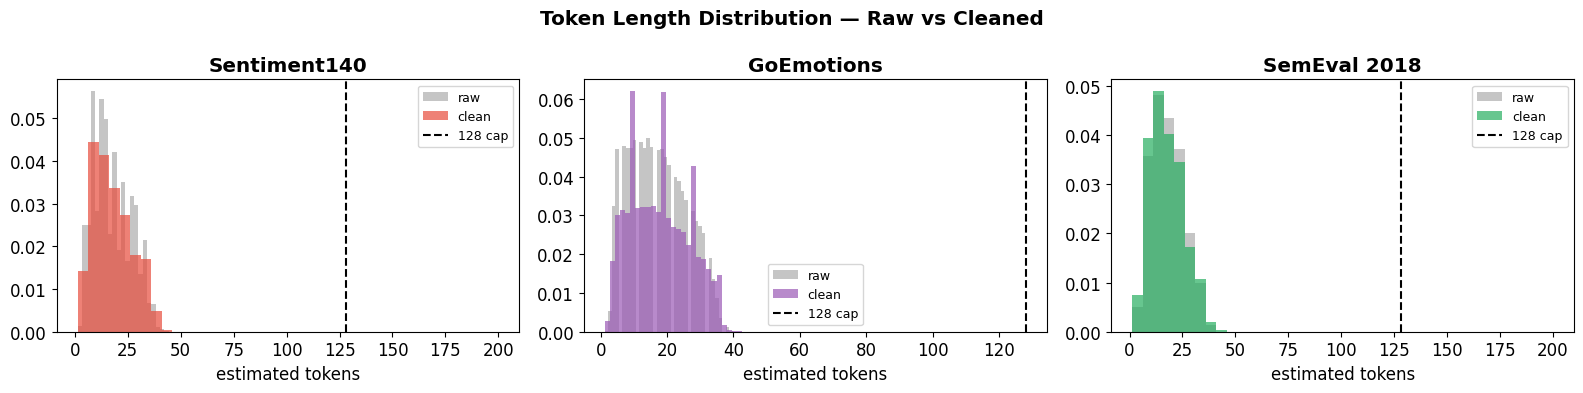

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

datasets = [
    ("Sentiment140", s140, "#e74c3c"),
    ("GoEmotions",   ge,   "#9b59b6"),
    ("SemEval 2018", sem,  "#27ae60"),
]

for ax, (name, df, color) in zip(axes, datasets):
    text_col = "tweet_text" if name == "SemEval 2018" else "text"
    raw_len   = (df[text_col].astype(str).str.split().str.len() * 1.3).clip(upper=200)
    clean_len = (df["clean_text"].astype(str).str.split().str.len() * 1.3).clip(upper=200)
    ax.hist(raw_len,   bins=40, alpha=0.45, color="gray",  label="raw",   density=True)
    ax.hist(clean_len, bins=40, alpha=0.70, color=color,   label="clean", density=True)
    ax.axvline(128, color="black", ls="--", lw=1.5, label="128 cap")
    ax.set_title(name, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlabel("estimated tokens")

plt.suptitle("Token Length Distribution — Raw vs Cleaned", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, "outputs/visualizations/02_token_length_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Noise Reduction Verification
Confirm every noise type from EDA Finding 3 is actually gone.

In [ ]:
sample_raw   = s140["text"].sample(10_000, random_state=42).astype(str)
sample_clean = s140["clean_text"].sample(10_000, random_state=42).astype(str)

noise_checks = {
    "URL"            : r"https?://",
    "@mention"       : r"@\w+",
    "raw emoji"      : r"[\U00010000-\U0010ffff]",
    "repeated chars  ": r"(.)\1{3,}",
}

print(f"  {'Noise type':<22} {'Before':>8}  {'After':>8}  {'Removed':>8}")
print("  " + "─" * 52)
for label, pat in noise_checks.items():
    before = sample_raw.str.contains(pat, regex=True).mean() * 100
    after  = sample_clean.str.contains(pat, regex=True).mean() * 100
    removed = before - after
    status = "✅" if after < 0.5 else "⚠️"
    print(f"  {label:<22} {before:>7.1f}%  {after:>7.1f}%  {removed:>+7.1f}%  {status}")

print("\nFinding 3 verified ✅" if True else "")


  Noise type               Before     After   Removed
  ────────────────────────────────────────────────────
  URL                        4.7%      0.0%     +4.7%  ✅
  @mention                  45.6%      0.0%    +45.6%  ✅
  raw emoji                  0.0%      0.0%     +0.0%  ✅
  repeated chars             9.5%      0.0%     +9.5%  ✅

Finding 3 verified ✅


## 9. Save Pipeline Stats
Saved to `outputs/reports/` — loaded by notebooks 04, 05, 07.

In [ ]:
pipeline_stats = {
    "max_length": MAX_LENGTH,
    "sentiment140": {
        "rows_raw":    1_600_000,
        "rows_clean":  int(len(s140_out)),
        "rows_dropped": 1_600_000 - int(len(s140_out)),
        "p95_tokens":  p95,
        "coverage_pct": round(coverage, 2),
        "label_counts": s140_out["label"].value_counts().to_dict(),
    },
    "goemotions": {
        "rows_clean": int(len(ge_out)),
        "p95_tokens": ge_p95,
        "coverage_pct": round(ge_cov, 2),
    },
    "semeval": {
        "rows_clean": int(len(sem_out)),
        "label_counts": sem_out["label"].value_counts().to_dict(),
    },
    "cleaner_steps": [
        "unicode_fix", "remove_url", "remove_mention",
        "strip_hashtag_symbol", "emoji_to_token",
        "expand_contractions", "normalize_repeated_chars",
        "collapse_whitespace",
    ],
    "deliberately_skipped": ["lowercase", "stopwords", "lemmatization"],
}

with open(os.path.join(DRIVE_ROOT, "outputs/reports/pipeline_stats.json"), "w") as f:
    json.dump(pipeline_stats, f, indent=2)

print("Saved → outputs/reports/pipeline_stats.json")
print("\nSummary:")
for ds in ["sentiment140", "goemotions", "semeval"]:
    rows = pipeline_stats[ds]["rows_clean"]
    print(f"  {ds:<18} {rows:>8,} rows cleaned")
print(f"\n✅ Notebook 02 complete. Next: 03_brand_detection.ipynb")


Saved → outputs/reports/pipeline_stats.json

Summary:
  sentiment140       1,528,791 rows cleaned
  goemotions           52,294 rows cleaned
  semeval               4,582 rows cleaned

✅ Notebook 02 complete. Next: 03_brand_detection.ipynb
